# Model 1: Index Return at t -> Stock Return at t

$$\text{AAPL Return}_t = \beta_0 + \beta_1 \cdot (\text{NASDAQ Return})_t + \varepsilon_t$$

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
tickers = ["^IXIC", "AAPL", "GOOGL"]
data = yf.download(tickers, start="2021-01-01", end="2026-06-01")
log_returns = np.log(data['Close'] / data['Close'].shift(1))
log_returns = log_returns.dropna()

[                       0%                       ]

[**********************67%*******                ]  2 of 3 completed

[*********************100%***********************]  3 of 3 completed

In [3]:
y = log_returns['AAPL']
x = log_returns['^IXIC']

X = sm.add_constant(x)
model1 = sm.OLS(y, X).fit()

model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   AAPL   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     1899.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          5.42e-260
Time:                        20:19:29   Log-Likelihood:                 4171.4
No. Observations:                1356   AIC:                            -8339.
Df Residuals:                    1354   BIC:                            -8328.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.488      0.625      -0.000       0.001
^IXIC          0.9397      0.022     43.579      0.000       0.897       0.982
==============================================================================
Omnibus:                      111.925   Durbin-Watson:                   1.838
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              521.692
Skew:                           0.223   Prob(JB):                    5.20e-114
Kurtosis:                       6.006   Cond. No.                         71.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [4]:
print(f"beta0 (intercept):     {model1.params['const']:.6f}  (p-value: {model1.pvalues['const']:.4g})")
print(f"beta1 (IXIC return):   {model1.params['^IXIC']:.6f}  (p-value: {model1.pvalues['^IXIC']:.4g})")
print(f"R-squared:             {model1.rsquared:.4f}")
print(f"Adjusted R-squared:    {model1.rsquared_adj:.4f}")

beta0 (intercept):     0.000148  (p-value: 0.6253)
beta1 (IXIC return):   0.939687  (p-value: 5.421e-260)
R-squared:             0.5838
Adjusted R-squared:    0.5835


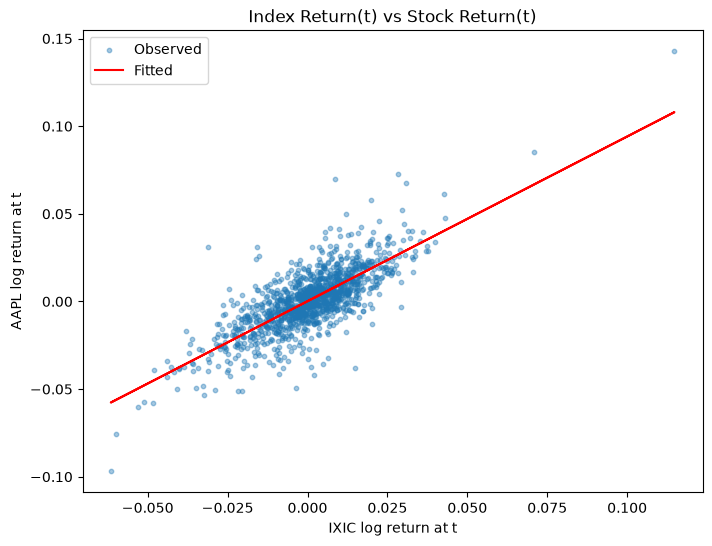

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.4, s=10, label="Observed")
plt.plot(x, model1.predict(X), color="red", label="Fitted")
plt.xlabel("IXIC log return at t")
plt.ylabel("AAPL log return at t")
plt.title("Index Return(t) vs Stock Return(t)")
plt.legend()
plt.show()

**Discussion — Model 1**

This model is a *contemporaneous* regression (both variables measured at time $t$), so it directly
addresses the question **"Can market index returns explain individual stock returns?"**. It does
**not** address "Can past returns predict future returns?", since same-day index data is not
available in advance — that requires a lagged predictor (e.g. $\text{IXIC}_{t-1}$).

Fitted model: $\widehat{\text{AAPL}}_t = 0.00015 + 0.940 \cdot \text{IXIC}_t$

- $\beta_1 = 0.940$ is highly significant ($p \approx 5\times10^{-260}$): AAPL's daily return
  co-moves almost one-for-one with the NASDAQ's daily return — consistent with AAPL having a
  market beta close to 1 (and being a large component of the index itself).
- $\beta_0 = 0.00015$ is not significant ($p = 0.625$): no evidence of an "alpha" beyond what is
  explained by the index.
- $R^2 = 0.584$, Adjusted $R^2 = 0.583$: about 58% of the day-to-day variance in AAPL's return is
  explained by the index return; the remaining ~42% is idiosyncratic (AAPL-specific) variation.
- Residual diagnostics: Durbin-Watson $\approx 1.84$ (close to 2, little residual autocorrelation),
  but the Jarque-Bera test strongly rejects normality and kurtosis $\approx 6$ indicates fat tails
  — typical for daily financial returns, and a reason to treat the classical $p$-values as
  approximate.

# Model 2

In [6]:
y = log_returns['AAPL']
x_lagged = log_returns['^IXIC'].shift(1)

df_temp = sm.add_constant(x_lagged)
df_temp['AAPL'] = y
df_temp = df_temp.dropna()

X = df_temp[['const', '^IXIC']]
y = df_temp['AAPL']

model2 = sm.OLS(y, X).fit()

model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   AAPL   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                  0.005167
Date:                Sat, 13 Jun 2026   Prob (F-statistic):              0.943
Time:                        20:19:29   Log-Likelihood:                 3574.2
No. Observations:                1355   AIC:                            -7144.
Df Residuals:                    1353   BIC:                            -7134.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      1.408      0.159      -0.000       0.002
^IXIC         -0.0024      0.033     -0.072      0.943      -0.068       0.063
==============================================================================
Omnibus:                      176.864   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1654.331
Skew:                           0.225   Prob(JB):                         0.00
Kurtosis:                       8.394   Cond. No.                         71.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
print(f"beta0 (intercept):     {model2.params['const']:.6f}  (p-value: {model2.pvalues['const']:.4g})")
print(f"beta1 (IXIC return):   {model2.params['^IXIC']:.6f}  (p-value: {model2.pvalues['^IXIC']:.4g})")
print(f"R-squared:             {model2.rsquared:.4f}")
print(f"Adjusted R-squared:    {model2.rsquared_adj:.4f}")

beta0 (intercept):     0.000663  (p-value: 0.1593)
beta1 (IXIC return):   -0.002403  (p-value: 0.9427)
R-squared:             0.0000
Adjusted R-squared:    -0.0007


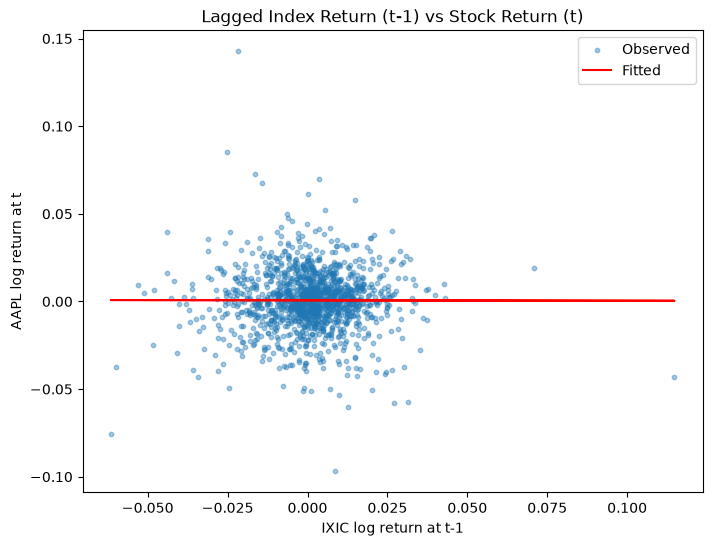

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X['^IXIC'], y, alpha=0.4, s=10, label="Observed")
plt.plot(X['^IXIC'], model2.predict(X), color="red", label="Fitted")
plt.xlabel("IXIC log return at t-1")
plt.ylabel("AAPL log return at t")
plt.title("Lagged Index Return (t-1) vs Stock Return (t)")
plt.legend()
plt.show()

**Discussion — Model 2**

This model regresses today's AAPL return on **yesterday's** NASDAQ return, so it directly
addresses **"Can past returns help predict future returns?"** (here, using the index's past
return to predict the stock's future return) — as opposed to Model 1, which only addressed
same-day co-movement.

Fitted model: $\widehat{\text{AAPL}}_t = 0.00066 - 0.0024 \cdot \text{IXIC}_{t-1}$

- $\beta_1 = -0.0024$ is not significant ($p = 0.943$): yesterday's NASDAQ return has
  essentially **no** linear relationship with today's AAPL return.
- $\beta_0 = 0.00066$ is also not significant ($p = 0.159$): no detectable average drift either.
- $R^2 \approx 0.0000$, Adjusted $R^2 \approx -0.0007$ (slightly negative because the one
  predictor adds no explanatory power beyond the sample mean): the lagged index return explains
  essentially none of the variance in AAPL's return.

**Answer:** No — lagged (one-day-old) market index returns do **not** help predict next-day AAPL
returns. This is consistent with the (weak-form) Efficient Market Hypothesis: publicly available
past price information (yesterday's index move) is already reflected in today's price and cannot
be used to forecast tomorrow's return.

# Model 3: Google Return at t -> Apple Return at t

$$\text{AAPL Return}_t = \beta_0 + \beta_1 \cdot (\text{GOOGL Return})_t + \varepsilon_t$$

In [9]:
y = log_returns['AAPL']
x = log_returns['GOOGL']

X = sm.add_constant(x)
model3 = sm.OLS(y, X).fit()

model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   AAPL   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     619.5
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          6.47e-113
Time:                        20:19:29   Log-Likelihood:                 3832.5
No. Observations:                1356   AIC:                            -7661.
Df Residuals:                    1354   BIC:                            -7651.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.319      0.750      -0.001       0.001
GOOGL          0.4963      0.020     24.891      0.000       0.457       0.535
==============================================================================
Omnibus:                      120.649   Durbin-Watson:                   1.909
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.185
Skew:                           0.124   Prob(JB):                    1.01e-154
Kurtosis:                       6.534   Cond. No.                         51.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
print(f"beta0 (intercept):     {model3.params['const']:.6f}  (p-value: {model3.pvalues['const']:.4g})")
print(f"beta1 (GOOGL return):  {model3.params['GOOGL']:.6f}  (p-value: {model3.pvalues['GOOGL']:.4g})")
print(f"R-squared:             {model3.rsquared:.4f}")
print(f"Adjusted R-squared:    {model3.rsquared_adj:.4f}")

beta0 (intercept):     0.000125  (p-value: 0.7496)
beta1 (GOOGL return):  0.496264  (p-value: 6.469e-113)
R-squared:             0.3139
Adjusted R-squared:    0.3134


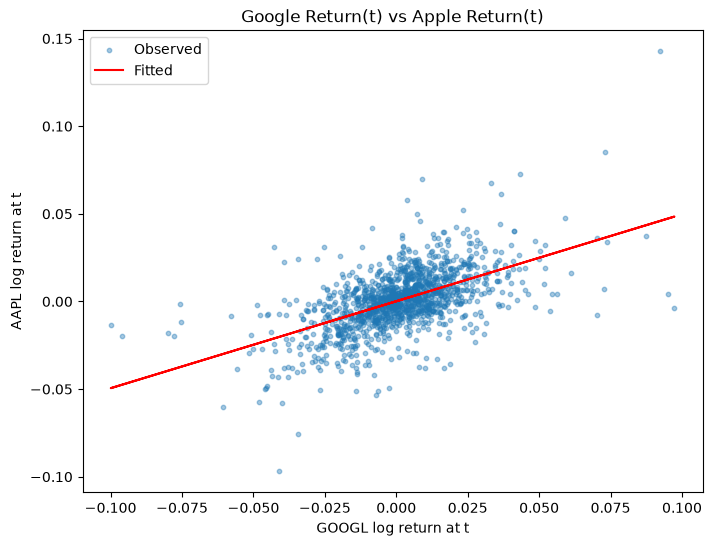

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.4, s=10, label="Observed")
plt.plot(x, model3.predict(X), color="red", label="Fitted")
plt.xlabel("GOOGL log return at t")
plt.ylabel("AAPL log return at t")
plt.title("Google Return(t) vs Apple Return(t)")
plt.legend()
plt.show()

**Discussion — Model 3**

This model is a *contemporaneous* regression of AAPL's return on GOOGL's return (both at time
$t$), so it addresses **"Can one stock's returns explain another stock's returns?"** — but, like
Model 1, only in the sense of same-day co-movement, not forecasting.

Fitted model: $\widehat{\text{AAPL}}_t = 0.00013 + 0.496 \cdot \text{GOOGL}_t$

- $\beta_1 = 0.496$ is highly significant ($p \approx 6.5\times10^{-113}$): a 1% same-day move in
  GOOGL's return is associated with a ~0.5% move in AAPL's return, in the same direction.
- $\beta_0 = 0.00013$ is not significant ($p = 0.750$): no detectable "alpha".
- $R^2 = 0.314$, Adjusted $R^2 = 0.313$: GOOGL's same-day return explains about 31% of AAPL's
  return variance — notably less than the ~58% explained by the NASDAQ index in Model 1.
- Residuals again show fat tails (kurtosis $\approx 6.5$, Jarque-Bera rejects normality), as in
  the other models.

**Answer:** Yes — one stock's return can explain another's, but the relationship is largely
driven by both stocks' shared exposure to common market/sector factors (both are large NASDAQ
tech stocks) rather than a direct causal link from GOOGL to AAPL. Consistent with this, GOOGL
alone explains less variance (31%) than the broad market index did (58%), since the index
captures the common factor more directly.